# 01. Start here: pySTAMPS pipeline

This is the short user guide inside a notebook. It shows the API, the dataset model, stage meanings, safe execution flow, and one diagnostic plot from the bundled golden dataset.

Rule of use: run pySTAMPS on a copy of your dataset because stage outputs are written into the dataset tree.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from pystamps.config import RunConfig
from pystamps.input_contracts import describe_stage_inputs
from pystamps.notebooks import load_velocity_diagnostics, sample_points
from pystamps.pipeline.stages import STAGE_DEFS, run_pipeline
from pystamps.pipeline.types import PipelineContext
from pystamps.status import collect_status

REPO_ROOT = Path.cwd()
DATASET = REPO_ROOT / "inputs_and_outputs" / "InSAR_dataset_test_stage8diag"

print(f"repo: {REPO_ROOT}")
print(f"dataset exists: {DATASET.exists()} -> {DATASET}")


repo: /shared/home/rdelprete/PythonProjects/AgenticWork/pySTAMPS
dataset exists: True -> /shared/home/rdelprete/PythonProjects/AgenticWork/pySTAMPS/inputs_and_outputs/InSAR_dataset_test_stage8diag


## 1. Inspect before running

`status` is the first command to run on any dataset. It tells you which patch and merged artifacts already exist.


In [2]:
status = collect_status(DATASET)

summary = pd.DataFrame([
    {
        "dataset": status.dataset.name,
        "merged_stage": status.merged_stage,
        "patch_count": len(status.patch_statuses),
    }
])
patches = pd.DataFrame([{"patch": p.patch, "patch_stage": p.stage} for p in status.patch_statuses])

display(summary)
display(patches)


,dataset,merged_stage,patch_count
0,InSAR_dataset_test_stage8diag,8,1


,patch,patch_stage
0,PATCH_1,5


## 2. Understand the stage map

The pipeline is stage based. Stages 1-5 run per patch; stages 6-8 run once at the merged dataset root. Stage 5 bridges both worlds.


In [3]:
stage_titles = {row["stage"]: row["title"] for row in describe_stage_inputs("all")}
stage_outputs = {
    1: "PATCH_*/ps1.mat, ph1.mat, bp1.mat",
    2: "PATCH_*/pm1.mat",
    3: "PATCH_*/select1.mat",
    4: "PATCH_*/weed1.mat",
    5: "PATCH_*/ph2.mat + root ifgstd2.mat",
    6: "root phuw2.mat, uw_grid.mat, uw_interp.mat",
    7: "root scla2.mat, scla_smooth2.mat",
    8: "root mean_v.mat, uw_space_time.mat",
}
stage_why = {
    1: "Organize raw candidates and metadata.",
    2: "Estimate phase model and coherence-like quality.",
    3: "Select persistent scatterer candidates.",
    4: "Remove noisy or redundant candidates.",
    5: "Promote patches into merged products.",
    6: "Unwrap merged phase.",
    7: "Estimate SCLA and correction terms.",
    8: "Apply final space-time filtering.",
}
stage_rows = []
for stage in STAGE_DEFS:
    stage_rows.append({
        "stage": stage.stage_id,
        "scope": stage.scope,
        "plain_language_goal": stage_why[stage.stage_id],
        "contract_title": stage_titles[stage.stage_id],
        "main_outputs": stage_outputs[stage.stage_id],
    })

display(pd.DataFrame(stage_rows))


,stage,scope,plain_language_goal,contract_title,main_outputs
0,1,patch,Organize raw candidates and metadata.,Load and organize raw candidate inputs,"PATCH_*/ps1.mat, ph1.mat, bp1.mat"
1,2,patch,Estimate phase model and coherence-like quality.,Estimate phase model and coherence per patch,PATCH_*/pm1.mat
2,3,patch,Select persistent scatterer candidates.,Select persistent scatterers,PATCH_*/select1.mat
3,4,patch,Remove noisy or redundant candidates.,Weed noisy or redundant candidates,PATCH_*/weed1.mat
4,5,patch,Promote patches into merged products.,Merge patch outputs into one dataset view,PATCH_*/ph2.mat + root ifgstd2.mat
5,6,merged,Unwrap merged phase.,Unwrap the merged phase products,"root phuw2.mat, uw_grid.mat, uw_interp.mat"
6,7,merged,Estimate SCLA and correction terms.,Estimate slow trends and correction terms,"root scla2.mat, scla_smooth2.mat"
7,8,merged,Apply final space-time filtering.,Apply final space-time filtering,"root mean_v.mat, uw_space_time.mat"


## 3. See what Stage 1 expects

Stage inputs are logical arrays. Files are just one way to carry those arrays.


In [4]:
stage1_inputs = pd.DataFrame(describe_stage_inputs(1)[0]["inputs"])
display(stage1_inputs[["logical_input", "array_name", "shape_hint", "meaning"]])


,logical_input,array_name,shape_hint,meaning
0,candidate indices,ij,"[n_candidates, 3]","candidate id, azimuth row, range column"
1,complex candidate phase stack,ph,"[n_candidates, n_ifg]",one complex phase value per candidate and inte...
2,candidate longitude/latitude,lonlat,"[n_candidates, 2]",longitude and latitude for each candidate
3,patch width,width,scalar,range width of the patch raster
4,patch length,length,scalar,azimuth length of the patch raster
5,acquisition days,day,[n_ifg],slave acquisition dates used to build the time...
6,master acquisition day,master_day,scalar,the master date inserted into the image timeline
7,perpendicular baseline summary,bperp,[n_ifg],one perpendicular baseline value per interfero...
8,optional stability metric,D_A,[n_candidates],candidate stability values for QC and side out...
9,optional height prior,hgt,[n_candidates],per-candidate height values when available


## 4. Learn the command flow

These are the commands users should learn first. The same ideas are available through the Python API.


In [5]:
commands = pd.DataFrame([
    {
        "step": 1,
        "why": "Inspect the dataset layout and progress.",
        "command": "uv run pystamps status --dataset DATASET",
    },
    {
        "step": 2,
        "why": "Preview what would run before doing expensive work.",
        "command": "uv run pystamps run --dataset DATASET --start-step 1 --end-step 8 --dry-run",
    },
    {
        "step": 3,
        "why": "Run a chosen stage range on a copy of the data.",
        "command": "uv run pystamps run --dataset DATASET_COPY --start-step 6 --end-step 8",
    },
    {
        "step": 4,
        "why": "Compare a run copy against a trusted golden dataset.",
        "command": "uv run pystamps verify --run RUN_COPY --golden GOLDEN_DATASET",
    },
])
display(commands)


,step,why,command
0,1,Inspect the dataset layout and progress.,uv run pystamps status --dataset DATASET
1,2,Preview what would run before doing expensive ...,uv run pystamps run --dataset DATASET --start-...
2,3,Run a chosen stage range on a copy of the data.,uv run pystamps run --dataset DATASET_COPY --s...
3,4,Compare a run copy against a trusted golden da...,uv run pystamps verify --run RUN_COPY --golden...


## 5. Dry-run through the Python API

This dry-run uses the bundled dataset. Because the dataset already contains late-stage outputs, pySTAMPS reports `skipped_existing`. That is useful: it teaches that pySTAMPS is artifact driven and resumable.


In [6]:
context = PipelineContext(
    dataset_root=DATASET,
    run_config=RunConfig(),
    start_step=6,
    end_step=8,
    dry_run=True,
)
report = run_pipeline(context)
run_rows = [
    {
        "stage": r.stage_id,
        "scope": r.scope,
        "target": r.target,
        "status": r.status,
        "details": r.details,
    }
    for r in report.results
]
display(pd.DataFrame(run_rows))


,stage,scope,target,status,details
0,6,merged,InSAR_dataset_test_stage8diag,skipped_existing,phuw2.mat present
1,7,merged,InSAR_dataset_test_stage8diag,skipped_existing,scla2.mat present
2,8,merged,InSAR_dataset_test_stage8diag,skipped_existing,uw_space_time.mat present


## 6. Read one scientific output

The final products include velocity-like diagnostics. Here we load the bundled dataset and plot a small sample so the files become concrete.


,points,acquisition_dates,plot_mode,velocity_source,stability_source,velocity_min,velocity_max
0,69009,76,dos,mv2.mean_v,mv2.mean_v_std,-20.266275,22.874037


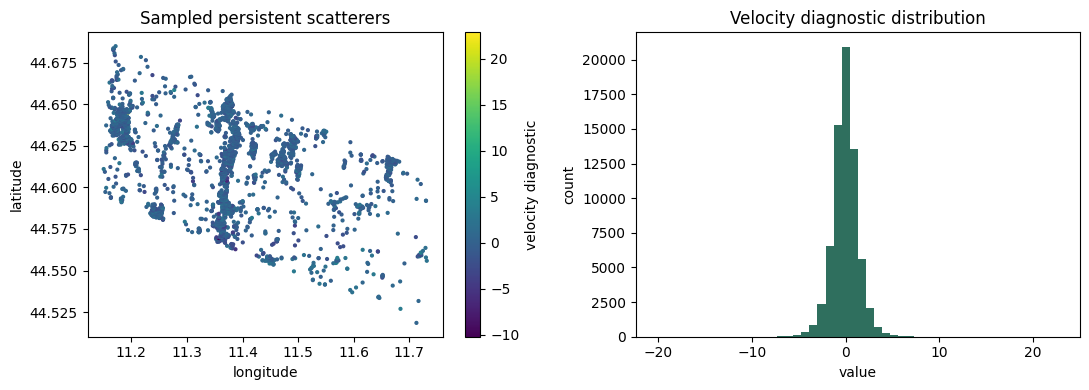

In [7]:
diag = load_velocity_diagnostics(DATASET, apply_step8=True, load_coherence=True)
summary = pd.DataFrame([
    {
        "points": diag.lonlat.shape[0],
        "acquisition_dates": diag.day.size,
        "plot_mode": diag.plot_mode,
        "velocity_source": diag.velocity_source,
        "stability_source": diag.stability_source,
        "velocity_min": float(np.nanmin(diag.velocity)),
        "velocity_max": float(np.nanmax(diag.velocity)),
    }
])
display(summary)

points, values = sample_points(diag.lonlat, diag.velocity, limit=2500)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
scatter = axes[0].scatter(points[:, 0], points[:, 1], c=values, s=4, cmap="viridis")
axes[0].set_title("Sampled persistent scatterers")
axes[0].set_xlabel("longitude")
axes[0].set_ylabel("latitude")
fig.colorbar(scatter, ax=axes[0], label="velocity diagnostic")
axes[1].hist(diag.velocity[np.isfinite(diag.velocity)], bins=50, color="#2f6f5e")
axes[1].set_title("Velocity diagnostic distribution")
axes[1].set_xlabel("value")
axes[1].set_ylabel("count")
fig.tight_layout()
plt.show()


## What to do next

Use notebook 02 when you need to switch Python/native/CUDA backends, run a parity smoke check, and collect timing evidence.
